<img src="https://upload.wikimedia.org/wikipedia/ro/thumb/1/18/Logo_UAIC_Iasi.svg/250px-Logo_UAIC_Iasi.svg.png"/>

# Task 1: Univariate Analysis

Characterization of individual variables using descriptive statistical techniques, including measures of central tendency (mean, median, mode), variability (variance, standard deviation, range, interquartile range), distributional shape (skewness, kurtosis), frequency distributions for categorical variables, and graphical representations such as boxplots, histograms, and density plots.

* * *

#### Setup

In [1]:
# Import the necessary library
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
# import seaborn library
import seaborn as sns
import numbers

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import cm

# pathlib
from pathlib import Path

In [2]:

LCL_PATH   = str(Path().cwd())
ROOT_PATH  = str(Path(LCL_PATH))
DS_PATH  = str(Path(LCL_PATH)/"data/heart_failure_prediction")
info_msg = """
root path:\t{}
local path:\t{}
dataset path:\t{}""".format(ROOT_PATH, LCL_PATH, DS_PATH)
print(info_msg)


root path:	/home/gheorghe/Desktop/Proiecte/master/DM
local path:	/home/gheorghe/Desktop/Proiecte/master/DM
dataset path:	/home/gheorghe/Desktop/Proiecte/master/DM/data/heart_failure_prediction


In [3]:

# adding local_folder to the system path
sys.path.append(ROOT_PATH)

from sys_function import * # este in root

# Data Manipulation

### Read and analyse data

In [4]:

# read auto data
name = "heart.csv"
filename = "{}/{}".format(DS_PATH, name)
pd_df_data = pd.read_csv(filename)

In [5]:
pd_df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
pd_df_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
pd_df_data.describe(include="all")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


**Conclusion:**

After inspecting and visualizing the heart disease dataset, it is evident that it contains both categorical and continuous variables. Therefore, accurate classification requires machine learning models capable of handling mixed data types, i.e., features with both categorical and numerical distributions.

### Decode status from features

In this subsection, the category labels are renamed to improve clarity regarding the data types being analyzed and to facilitate more efficient interpretation of the dataset.

In [8]:
# update Sex field
def decSexField(data):
  if (data == "M"):
    return "Male"
  elif (data == "F"):
    return "Female"
pd_df_data["Sex"] = pd_df_data["Sex"].apply(decSexField)

In [9]:
# update FastingBS field
def decFastingBSField(data):
  if (data == 1):
    return "FastingBS"
  elif (data == 0):
    return "otherwise"
pd_df_data["FastingBS"] = pd_df_data["FastingBS"].apply(decFastingBSField)

In [10]:
# update ExerciseAngina field
def decExerciseAnginaField(data):
  if (data == "N"):
    return "No"
  elif (data == "Y"):
    return "Yes"
pd_df_data["ExerciseAngina"] = pd_df_data["ExerciseAngina"].apply(decExerciseAnginaField)

In [11]:
# update HeartDisease field
def decHeartDiseaseField(data):
  if (data == 0):
    return "No"
  elif (data == 1):
    return "Yes"
pd_df_data["HeartDisease"] = pd_df_data["HeartDisease"].apply(decHeartDiseaseField)

In [12]:
pd_df_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,Male,ATA,140,289,otherwise,Normal,172,No,0.0,Up,No
1,49,Female,NAP,160,180,otherwise,Normal,156,No,1.0,Flat,Yes
2,37,Male,ATA,130,283,otherwise,ST,98,No,0.0,Up,No
3,48,Female,ASY,138,214,otherwise,Normal,108,Yes,1.5,Flat,Yes
4,54,Male,NAP,150,195,otherwise,Normal,122,No,0.0,Up,No


In [13]:
pd_df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    object 
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    object 
dtypes: float64(1), int64(4), object(7)
memory usage: 86.2+ KB


In [14]:
pd_df_data.describe(include="all")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918,918,918.000000,918,918.000000,918,918
unique,NaN,2,4,NaN,NaN,2,3,NaN,2,NaN,3,2
top,NaN,Male,ASY,NaN,NaN,otherwise,Normal,NaN,No,NaN,Flat,Yes
freq,NaN,725,496,NaN,NaN,704,552,NaN,547,NaN,460,508
mean,53.510893,NaN,NaN,132.396514,198.799564,NaN,NaN,136.809368,NaN,0.887364,NaN,NaN
std,9.432617,NaN,NaN,18.514154,109.384145,NaN,NaN,25.460334,NaN,1.066570,NaN,NaN
min,28.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN
25%,47.000000,NaN,NaN,120.000000,173.250000,NaN,NaN,120.000000,NaN,0.000000,NaN,NaN
50%,54.000000,NaN,NaN,130.000000,223.000000,NaN,NaN,138.000000,NaN,0.600000,NaN,NaN
75%,60.000000,NaN,NaN,140.000000,267.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN


### Slice data by heart disease

The dataset is partitioned into two subsets—patients with heart disease and patients without heart disease—to enable clearer and more effective visualization.

In [15]:

# create group by Heart Disease
pd_df_grouped = pd_df_data.groupby("HeartDisease")
# create group by Heart Disease, yes
pd_df_disease_yes = pd_df_grouped.get_group("Yes")
# create group by Heart Disease, no
pd_df_disease_no = pd_df_grouped.get_group("No")

In [16]:
a = pd_df_data["Age"].value_counts()
b = pd_df_disease_yes["Age"].value_counts()
d = pd_df_disease_no["Age"].value_counts()
c = pd.merge(a, b, left_index=True, right_index=True, how='outer').fillna(0)
e = pd.merge(c, d, left_index=True, right_index=True, how='outer').fillna(0)
e.columns = ['total', 'yes', 'no']
print(e)

     total   yes    no
Age                   
28       1   0.0   1.0
29       3   0.0   3.0
30       1   0.0   1.0
31       2   1.0   1.0
32       5   2.0   3.0
33       2   1.0   1.0
34       7   2.0   5.0
35      11   4.0   7.0
36       6   2.0   4.0
37      11   1.0  10.0
38      16  11.0   5.0
39      15   2.0  13.0
40      13   6.0   7.0
41      24   6.0  18.0
42      18   3.0  15.0
43      24  11.0  13.0
44      19   6.0  13.0
45      18   3.0  15.0
46      24  13.0  11.0
47      19  11.0   8.0
48      31  15.0  16.0
49      21  11.0  10.0
50      25  14.0  11.0
51      35  15.0  20.0
52      36  19.0  17.0
53      33  15.0  18.0
54      51  23.0  28.0
55      41  24.0  17.0
56      38  25.0  13.0
57      38  26.0  12.0
58      42  28.0  14.0
59      35  23.0  12.0
60      32  24.0   8.0
61      31  26.0   5.0
62      35  25.0  10.0
63      30  23.0   7.0
64      22  15.0   7.0
65      21  15.0   6.0
66      13   7.0   6.0
67      15  12.0   3.0
68      10   6.0   4.0
69      13 

# Functions

## Slice function

In [17]:
# count attrition status of the features
def sliceDataByFeatures(pd_data, name_features):
  # create group by Heart Disease, yes
  pd_df_disease_yes = pd_df_grouped.get_group("Yes")
  # create group by Heart Disease, no
  pd_df_disease_no = pd_df_grouped.get_group("No")
  # count remain status of the features
  pd_s_count_features_yes = pd_df_disease_yes[name_features].value_counts()
  # count remain status of the features
  pd_s_count_features_no = pd_df_disease_no[name_features].value_counts()
  # count total number of every status for features
  pd_s_count_features = pd_data[name_features].value_counts()
  total_nbr_employe = pd_s_count_features.values

  c = pd.merge(pd_s_count_features, pd_s_count_features_no, left_index=True, right_index=True, how="outer").fillna(0)
  e = pd.merge(c, pd_s_count_features_yes, left_index=True, right_index=True, how="outer").fillna(0)
  # create dataframe by number of status
  e.sort_index()
  e.columns = ["total", "No", "Yes"]
  pd_df_count_status_value = pd.DataFrame([e["Yes"], e["No"], e["total"]], columns=e.index, index=["Heart disease", "Normal", "Total status"])
  return pd_df_count_status_value

In [18]:
pd_df_count = sliceDataByFeatures(pd_df_data, "Age")
pd_df_count

Age,28,29,30,31,32,33,34,35,36,37,...,68,69,70,71,72,73,74,75,76,77
Heart disease,0.0,0.0,0.0,1.0,2.0,1.0,2.0,4.0,2.0,1.0,...,6.0,10.0,6.0,2.0,3.0,1.0,5.0,2.0,1.0,2.0
Normal,1.0,3.0,1.0,1.0,3.0,1.0,5.0,7.0,4.0,10.0,...,4.0,3.0,1.0,3.0,1.0,0.0,2.0,1.0,1.0,0.0
Total status,1.0,3.0,1.0,2.0,5.0,2.0,7.0,11.0,6.0,11.0,...,10.0,13.0,7.0,5.0,4.0,1.0,7.0,3.0,2.0,2.0


## Heat map function

In [19]:
def pd_df_frequencyFeaturePivot_2x(pd_df_data, feature_1, feature_2):
  # Group by education field
  pd_s_count_eF_total = pd_df_data[[feature_1, feature_2]].value_counts().sort_index()
  # get the row and column name
  eF, e = zip(*np.array(pd_s_count_eF_total.index))
  pd_df_count_eF_total = pd.DataFrame({feature_1:e,feature_2:eF,'Total values':pd_s_count_eF_total.values})
  pd_df_count_pivot_eF_total = pd_df_count_eF_total.pivot(index=[feature_1], columns=[feature_2], values='Total values').fillna(0)
  return pd_df_count_pivot_eF_total

In [20]:
def heatmap_RGB_2D(pd_df_data, title):
  # When using a hue semantic with discrete data, it can make sense to “dodge” the levels:
  top = cm.get_cmap('Reds_r', 256)
  miedle = cm.get_cmap('Greens_r', 256)
  bottom = cm.get_cmap('Blues', 256)

  newcolors = np.vstack((bottom(np.linspace(0, 1, 90)),
                        miedle(np.linspace(0, 1, 90)),
                        top(np.linspace(1, 0, 90))))
  newcmp = ListedColormap(newcolors, name='heatmap_RGB')

  width, height = 40, 7
  plt.rcParams['figure.figsize'] = [width, height]
  sns.heatmap(pd_df_data, annot=True, cmap=newcmp)
  plt.title(title, fontsize = 20) # title with fontsize 20
  plt.show()

## PieChart

In [21]:
def pieChart(data, labels, title):
  fig1, ax = plt.subplots()
  ax.pie(data, labels=labels, autopct='%1.1f%%',
          shadow=False, startangle=0)
  ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
  ax.set_title(title)
  plt.show()

# Age distribution of heart disease

## Find the age distribution of heart disease

Skewness Value	Meaning

- ≈ 0  Symmetric
- > 0  Right-skewed (tail on right)
- < 0  Left-skewed (tail on left)

Excess Kurtosis	Meaning

- 0    Normal-like (mesokurtic)
- > 0  Heavy tails, peaked (leptokurtic)
- < 0  Light tails, flat (platykurtic)

In [62]:

# Skewness
skew_value = pd_df_data["Age"].skew()
print("Skewness:", skew_value)

# Kurtosis (excess)
kurt_value = pd_df_data["Age"].kurt()
print("Excess Kurtosis:", kurt_value)

Skewness: -0.19593302867569365
Excess Kurtosis: -0.3861396123864571


<Axes: xlabel='Age', ylabel='Count'>

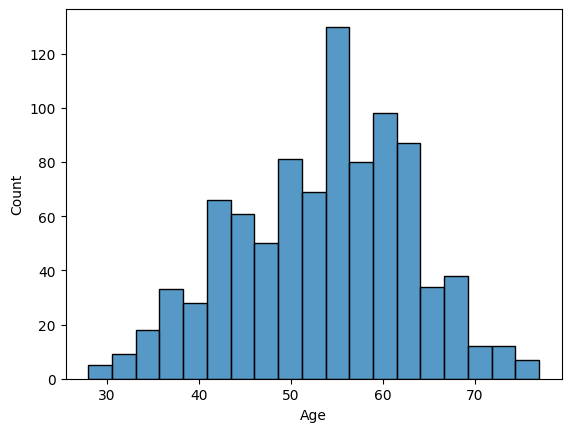

In [22]:
# the age distribution
sns.histplot(data=pd_df_data, x="Age")

<Axes: xlabel='Age', ylabel='Count'>

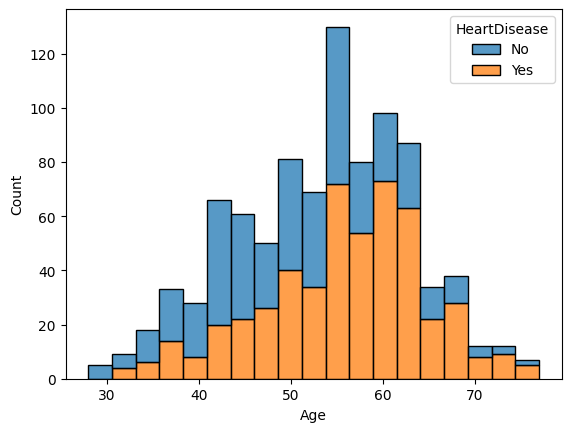

In [27]:
# The default approach to plotting multiple distributions is to “layer” them, but you can also “stack” them:
sns.histplot(data=pd_df_data, x="Age", hue="HeartDisease", multiple="stack")

<Axes: xlabel='Age', ylabel='Count'>

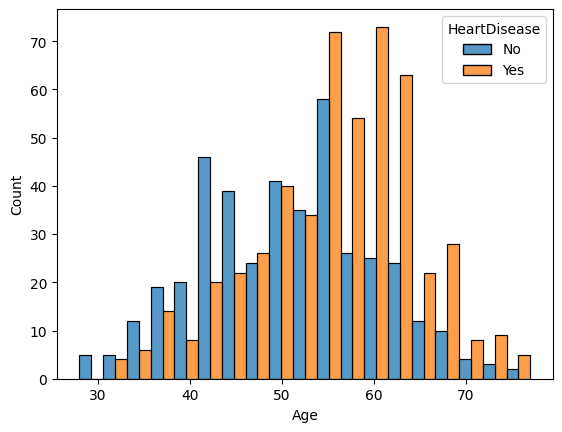

In [28]:
# The default approach to plotting multiple distributions is to “layer” them, but you can also “dodge” them:
sns.histplot(data=pd_df_data, x="Age", hue="HeartDisease", multiple="dodge")

### Age distribution of heart disease by percent

In [25]:
# groupe data by heart disease and slice by Age
pd_df_count = sliceDataByFeatures(pd_df_data, "Age")
# transpose data frame
pd_df_count_Transpose = pd_df_count.T

<Axes: xlabel='Age'>

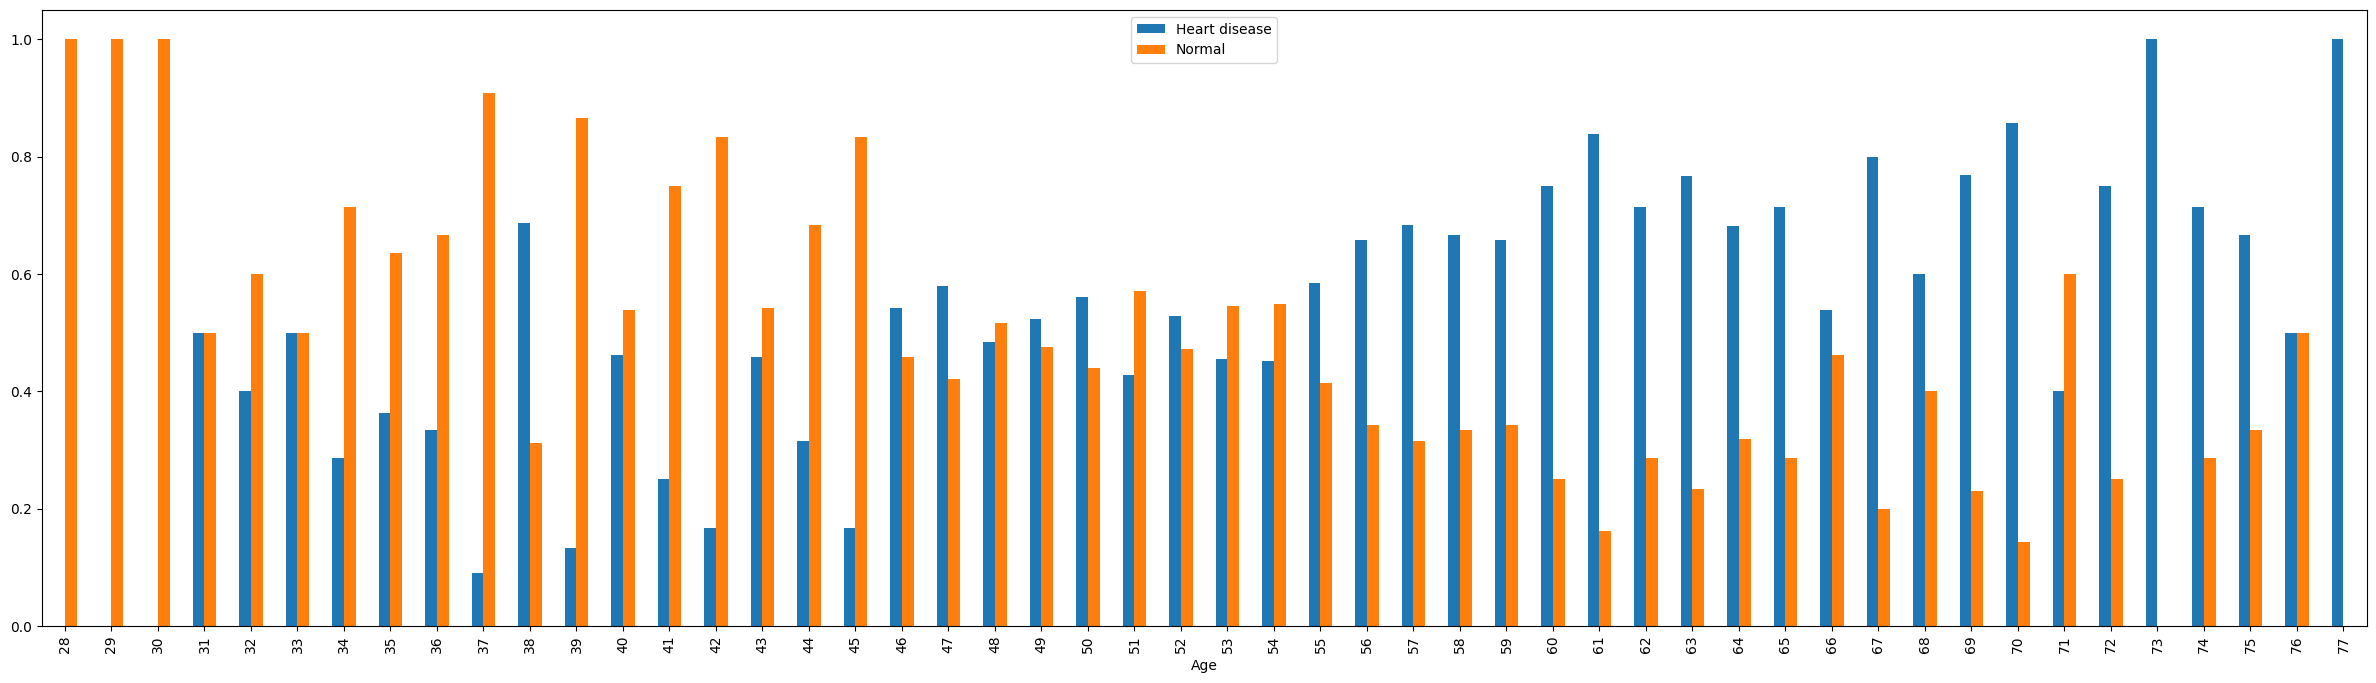

In [26]:
"Heart disease", "Normal", "Total status"
# calculate the percent of heart disease
p0 = pd_df_count_Transpose["Heart disease"] / pd_df_count_Transpose["Total status"]
# calculate the percent of normal
p1 = pd_df_count_Transpose["Normal"] / pd_df_count_Transpose["Total status"]
# create a data frame
p = pd.DataFrame({"Heart disease":np.array(p0), "Normal":np.array(p1)}, index=pd_df_count_Transpose.index)
# plot the percent of leave and stay employee
p.plot.bar(figsize=(30, 8))

### Age distribution, heart disease by frequency

<Axes: xlabel='Age'>

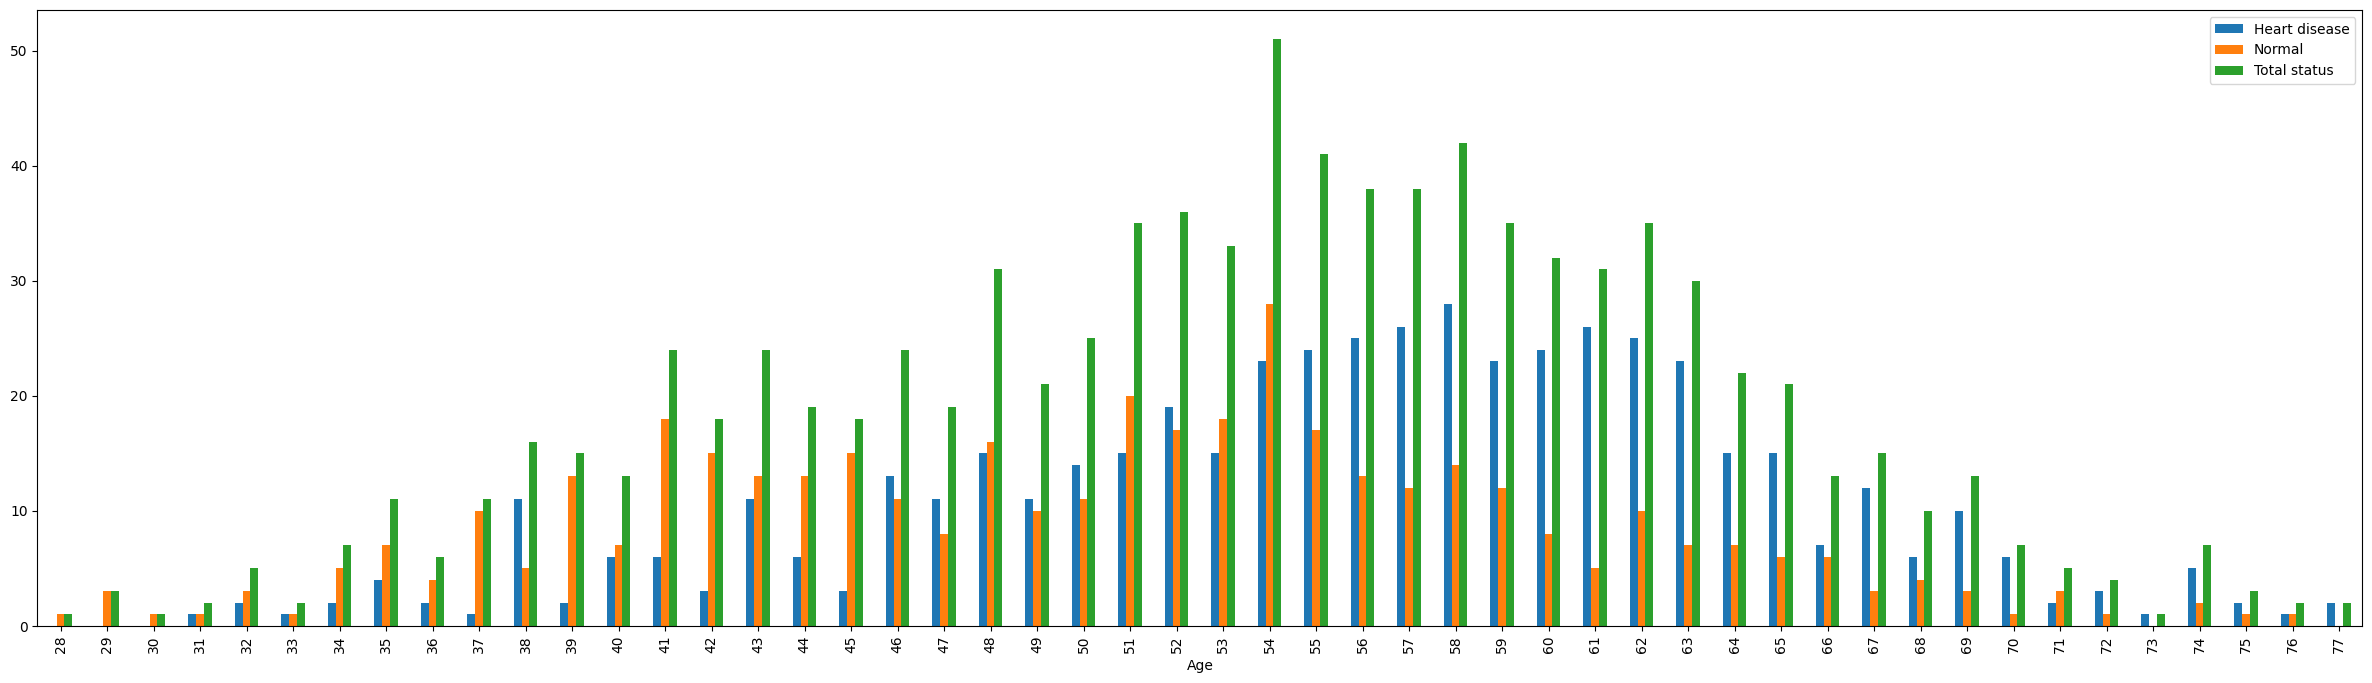

In [29]:
# plot number of employee by age
pd_df_count_Transpose.plot.bar(figsize=(30, 8))

**Conclusion:**

Following exploratory analysis of the heart disease dataset, the following observations can be made:
- The overall distribution exhibits negative skewness and is platykurtic (i.e., flatter than a normal distribution).
- Individuals aged up to 40 years present least frequently, suggesting a comparatively lower prevalence of health issues in this age group.
- Patients between 50 and 65 years of age show the highest consultation frequency.
- Individuals over 65 years of age appear less frequently in the dataset, likely due to the smaller representation of this age group in the sample.

## Age distribution, heart disease by sex

<Axes: xlabel='Age', ylabel='Count'>

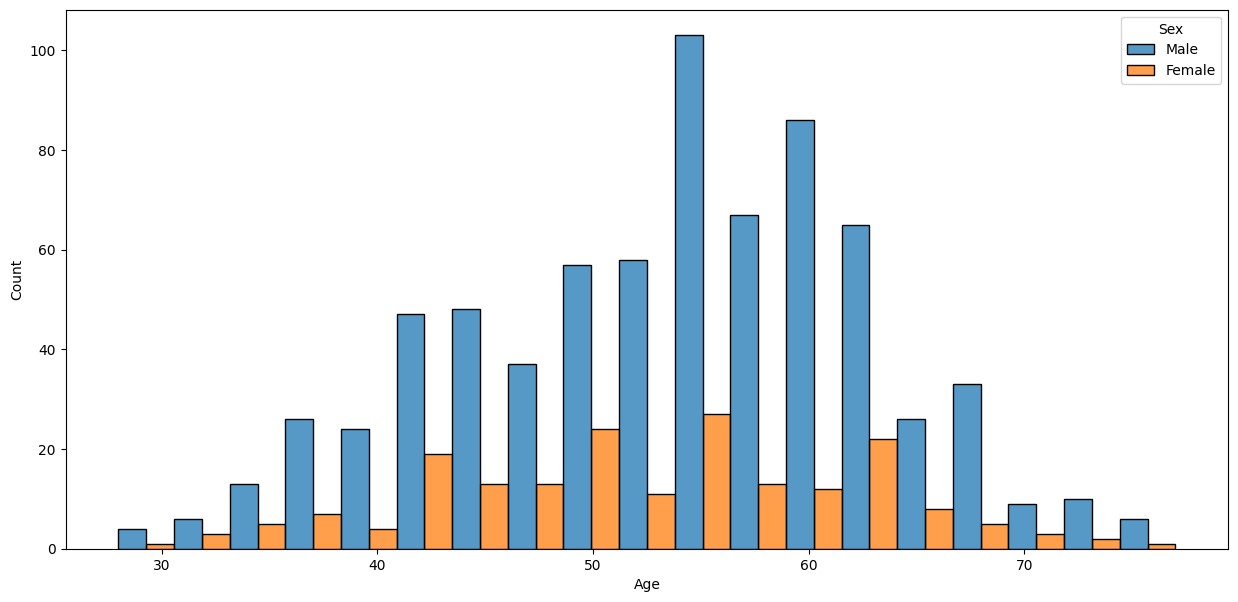

In [30]:
# When using a hue semantic with discrete data, it can make sense to “dodge” the levels:
width, height = 15, 7
plt.rcParams["figure.figsize"] = [width, height]
sns.histplot(data=pd_df_data, x="Age", hue="Sex", multiple="dodge")

<Axes: xlabel='Age', ylabel='Count'>

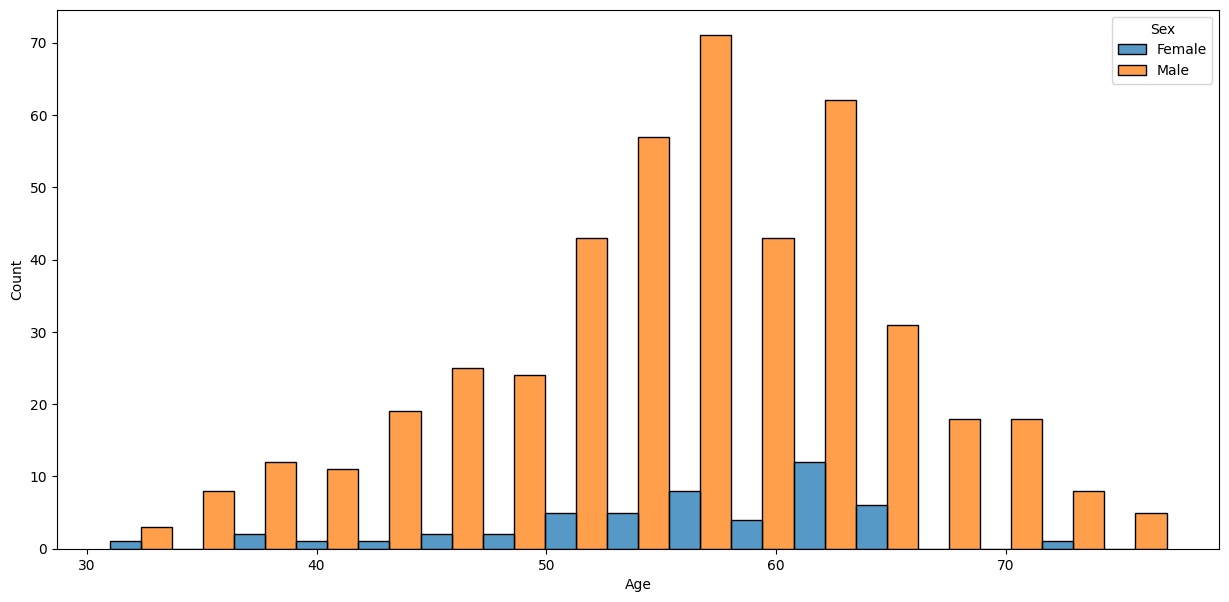

In [31]:
# When using a hue semantic with discrete data, it can make sense to “dodge” the levels:
width, height = 15, 7
plt.rcParams['figure.figsize'] = [width, height]
sns.histplot(data=pd_df_disease_yes, x="Age", hue="Sex", multiple="dodge")

<Axes: xlabel='Age', ylabel='Count'>

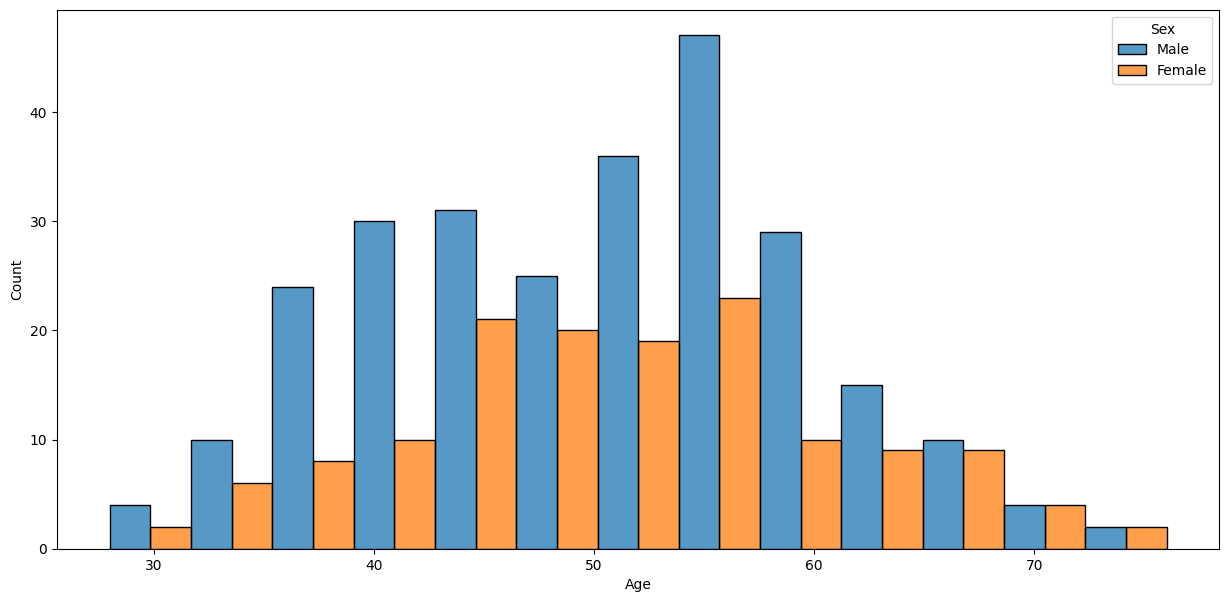

In [32]:
# When using a hue semantic with discrete data, it can make sense to “dodge” the levels:
width, height = 15, 7
plt.rcParams['figure.figsize'] = [width, height]
sns.histplot(data=pd_df_disease_no, x="Age", hue="Sex", multiple="dodge")

**Conclusion:**

Based on the exploratory analysis of the heart disease dataset, when stratifying by patient gender, the following patterns emerge:
- Male patients begin to present more frequently from approximately 35 years of age onward.
- The prevalence of heart disease is higher among male patients.

## Statistical calculation

In [33]:
pd_df_data.describe(include="all")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918,918,918.000000,918,918.000000,918,918
unique,NaN,2,4,NaN,NaN,2,3,NaN,2,NaN,3,2
top,NaN,Male,ASY,NaN,NaN,otherwise,Normal,NaN,No,NaN,Flat,Yes
freq,NaN,725,496,NaN,NaN,704,552,NaN,547,NaN,460,508
mean,53.510893,NaN,NaN,132.396514,198.799564,NaN,NaN,136.809368,NaN,0.887364,NaN,NaN
std,9.432617,NaN,NaN,18.514154,109.384145,NaN,NaN,25.460334,NaN,1.066570,NaN,NaN
min,28.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN
25%,47.000000,NaN,NaN,120.000000,173.250000,NaN,NaN,120.000000,NaN,0.000000,NaN,NaN
50%,54.000000,NaN,NaN,130.000000,223.000000,NaN,NaN,138.000000,NaN,0.600000,NaN,NaN
75%,60.000000,NaN,NaN,140.000000,267.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN


In [58]:
pd_df_data['Age'].agg(['max', 'min', 'std', 'mean', 'median'])

max       77.000000
min       28.000000
std        9.432617
mean      53.510893
median    54.000000
Name: Age, dtype: float64

In [60]:
pd_df_disease_yes['Age'].agg(['max', 'min', 'std', 'mean', 'median'])

max       77.000000
min       31.000000
std        8.727056
mean      55.899606
median    57.000000
Name: Age, dtype: float64

In [61]:
pd_df_disease_no['Age'].agg(['max', 'min', 'std', 'mean', 'median'])

max       76.000000
min       28.000000
std        9.444915
mean      50.551220
median    51.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Sex'>

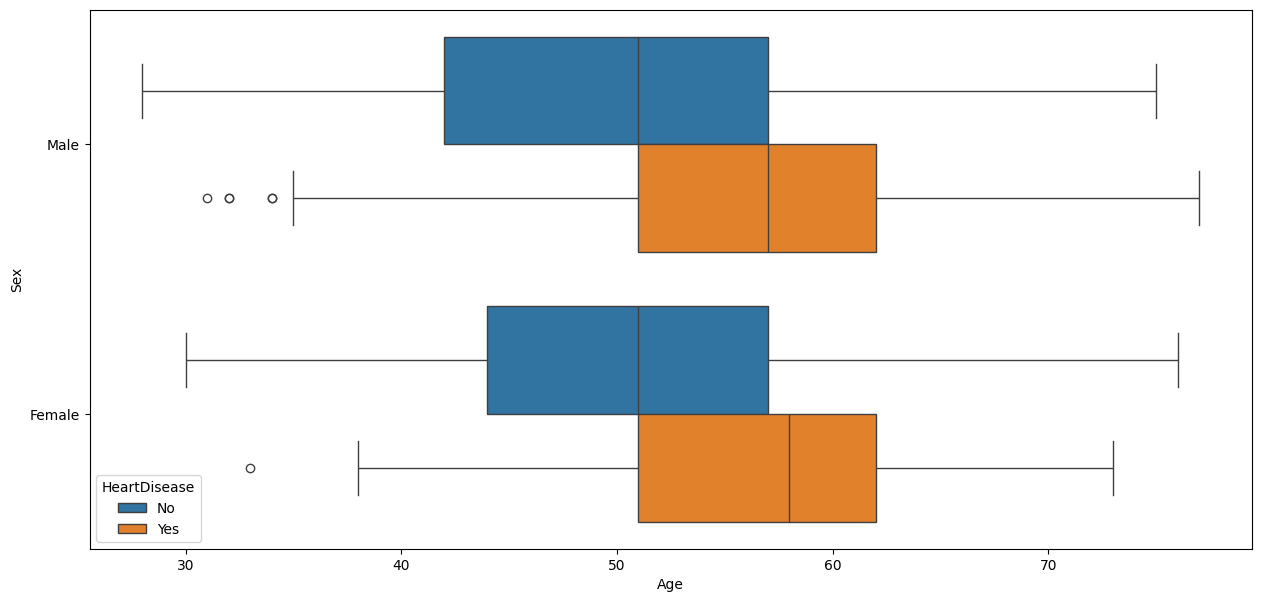

In [43]:
sns.boxplot(data=pd_df_data, x="Age", y="Sex", hue="HeartDisease")

# Explore HeartDisease by FastingBS

## HeartDisease by FastingBS

<Axes: xlabel='FastingBS', ylabel='Count'>

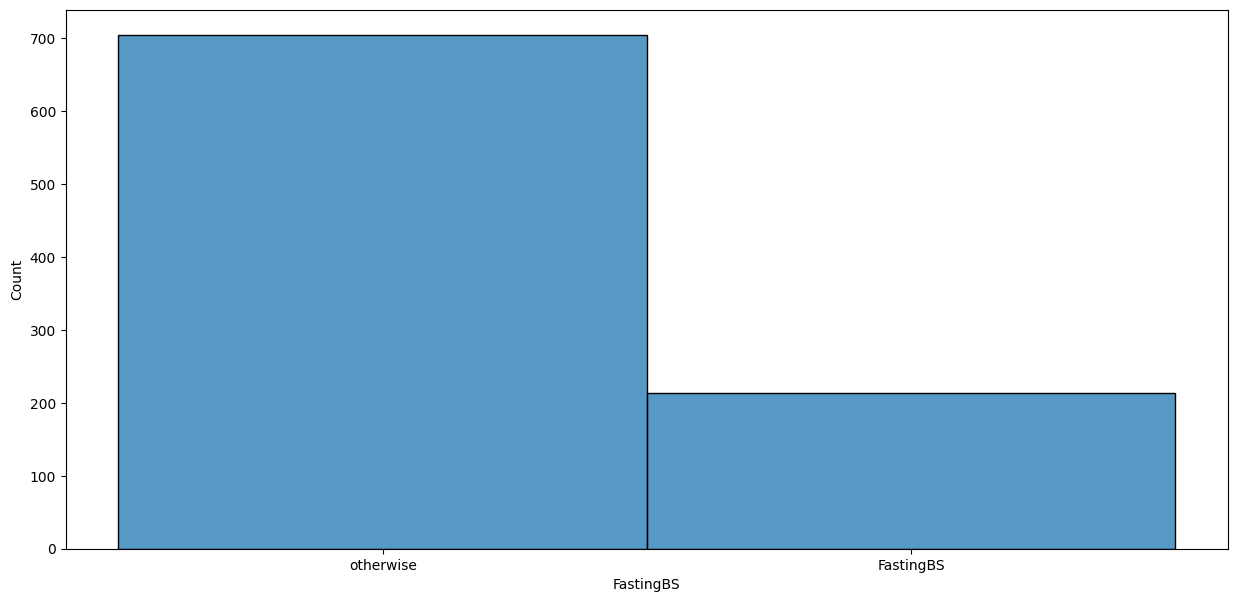

In [44]:
# When using a hue semantic with discrete data, it can make sense to “dodge” the levels:
sns.histplot(data=pd_df_data, x="FastingBS")

<Axes: xlabel='FastingBS', ylabel='Count'>

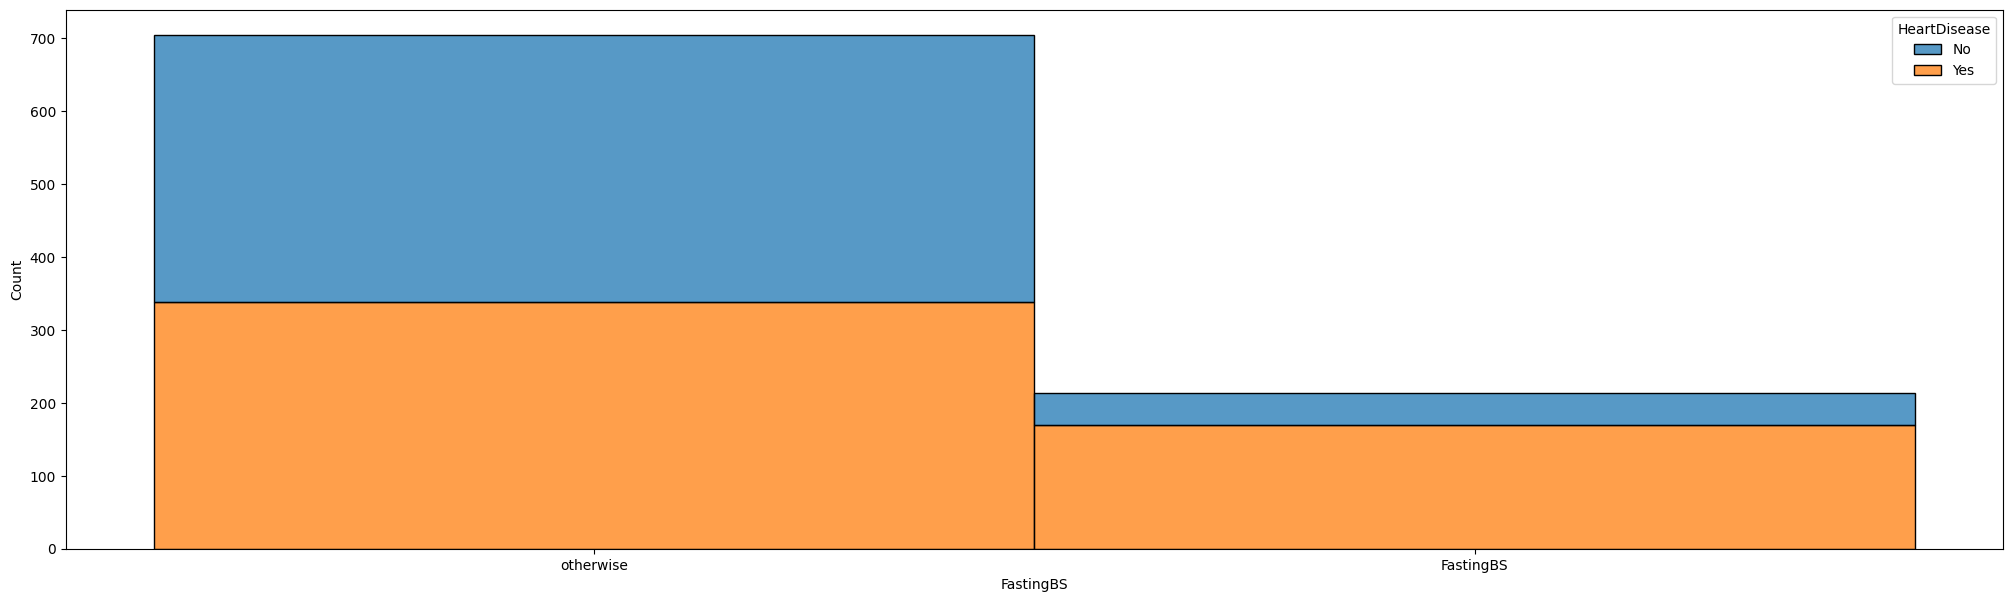

In [45]:
# When using a hue semantic with discrete data, it can make sense to “dodge” the levels:
width, height = 25, 7
plt.rcParams['figure.figsize'] = [width, height]
sns.histplot(data=pd_df_data, x="FastingBS", hue="HeartDisease", multiple="stack")

## Heart disease percent by FastingBS

In [46]:
# groupe data by attrition and slice by Age
pd_df_count = sliceDataByFeatures(pd_df_data, "FastingBS")
# transpose data frame
pd_df_count_Transpose = pd_df_count.T

In [47]:
pd_df_count_Transpose

,Heart disease,Normal,Total status
FastingBS,,,
FastingBS,170,44,214
otherwise,338,366,704


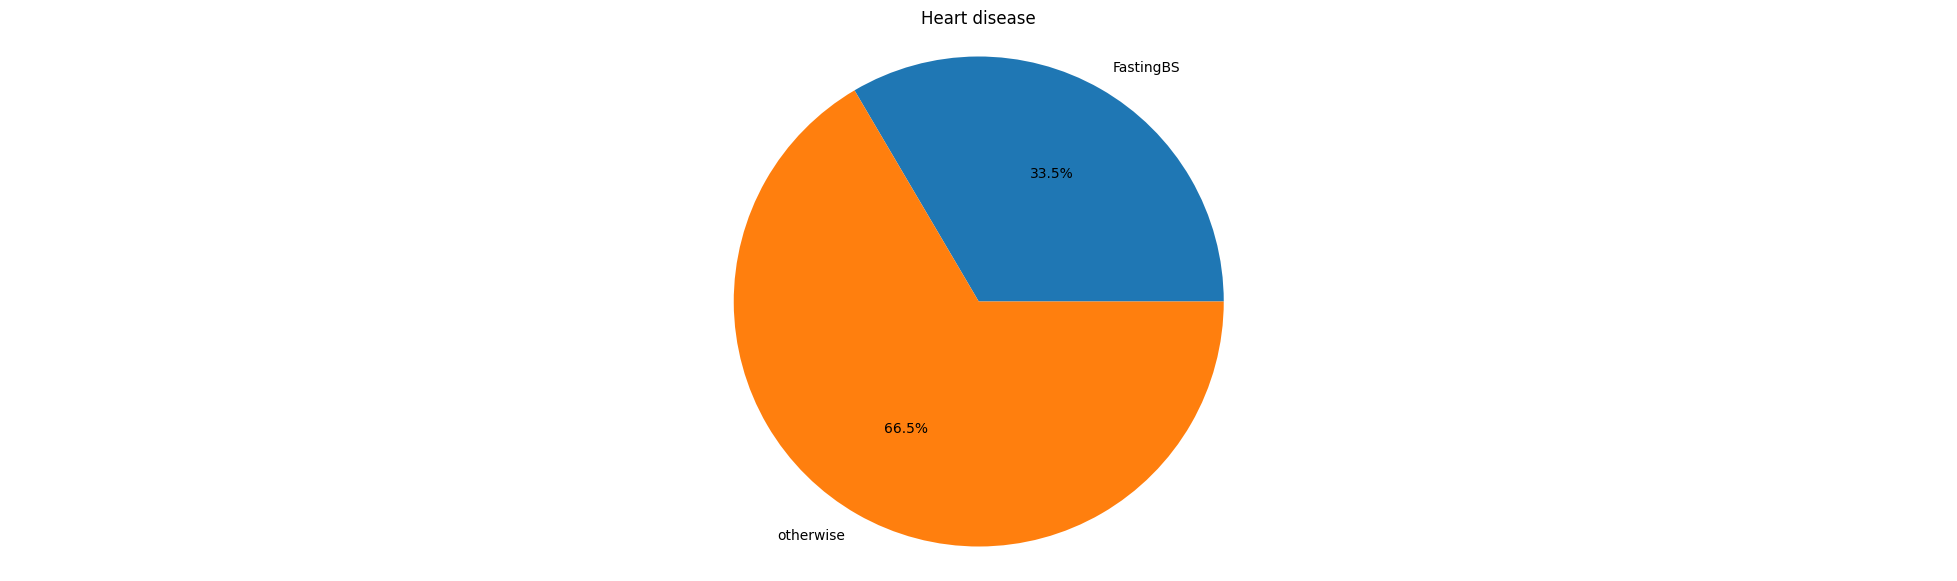

In [48]:
# Pie chart, where the slices will be ordered and plotted counter-clockwise:
pieChart(pd_df_count_Transpose["Heart disease"].values, pd_df_count_Transpose["Heart disease"].index, "Heart disease")

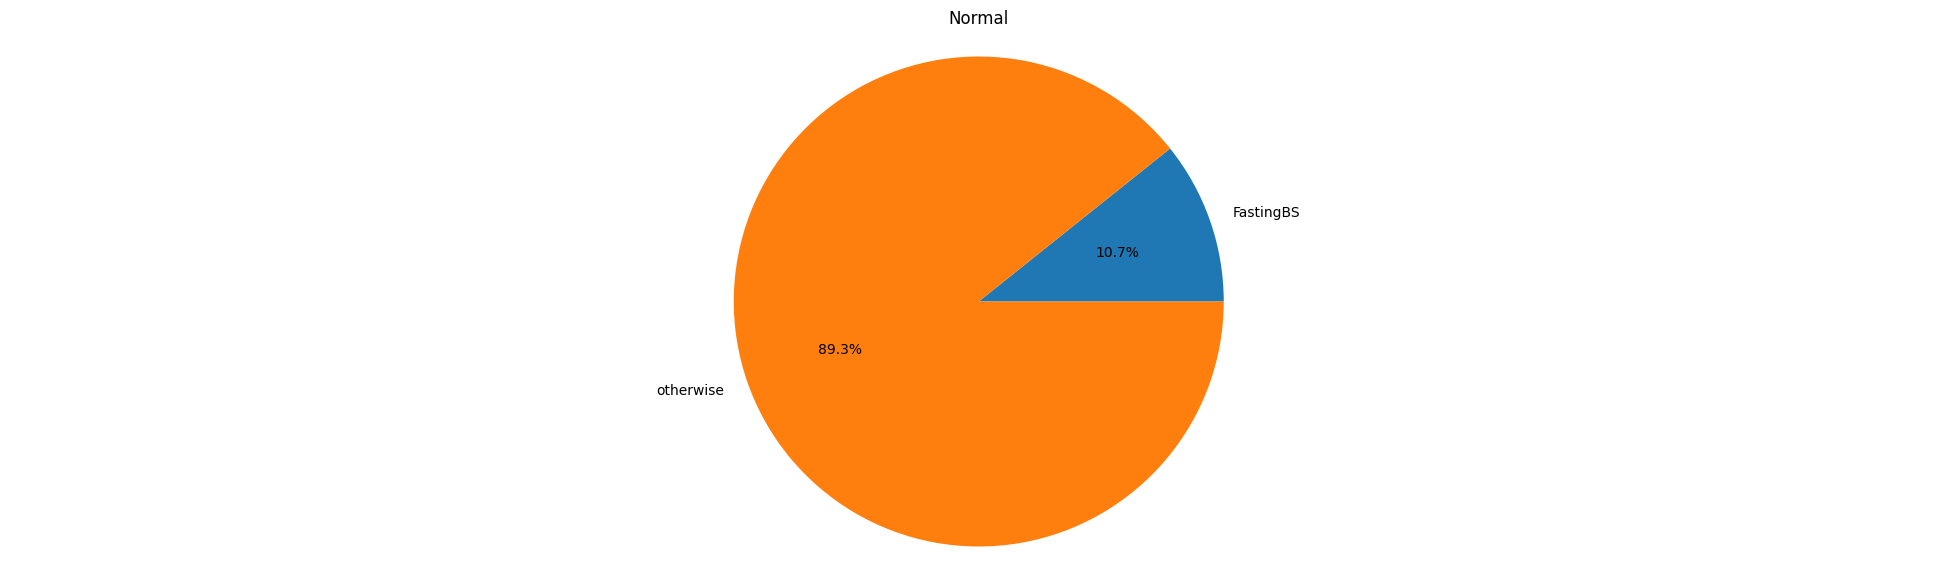

In [49]:
# Pie chart, where the slices will be ordered and plotted counter-clockwise:
pieChart(pd_df_count_Transpose["Normal"].values, pd_df_count_Transpose["Normal"].index, "Normal")

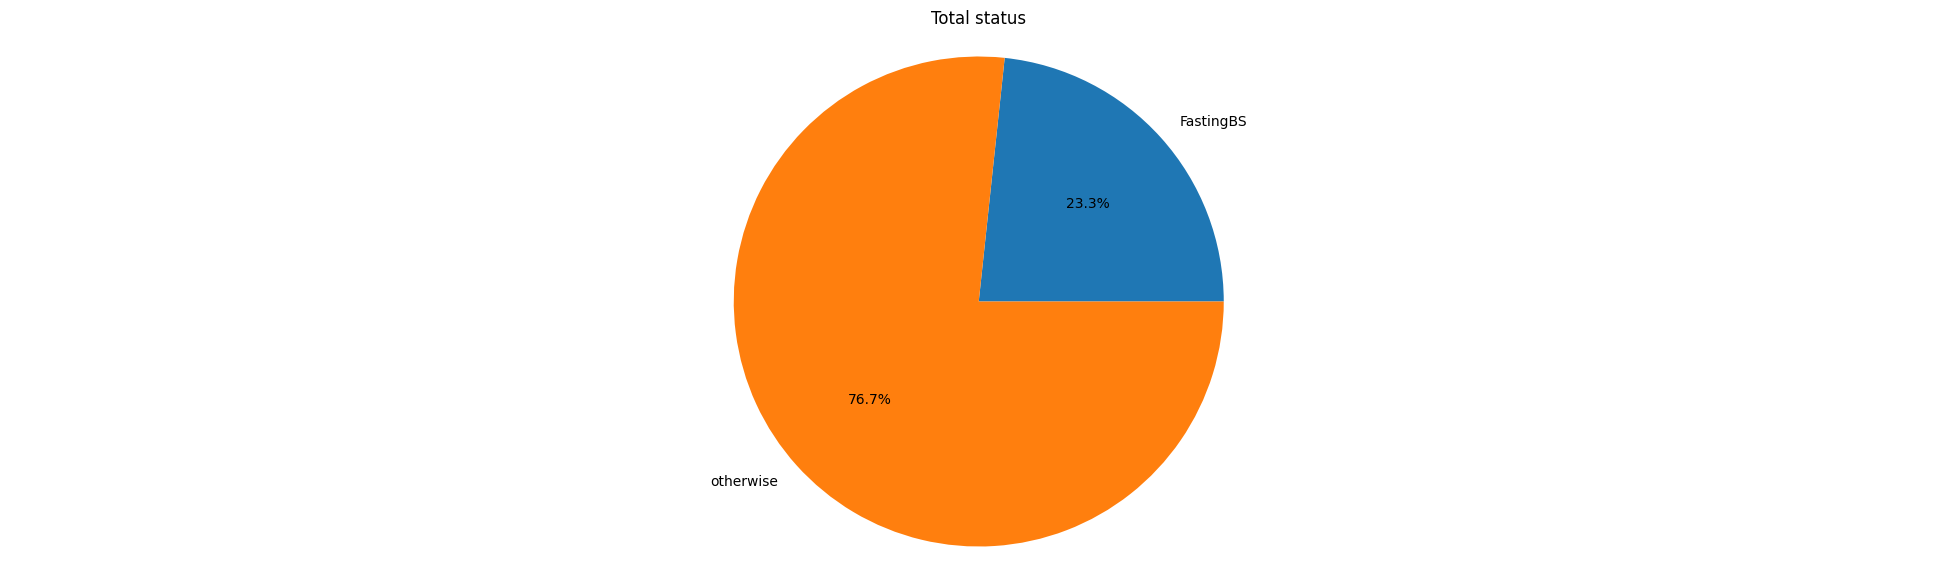

In [50]:
# Pie chart, where the slices will be ordered and plotted counter-clockwise:
pieChart(pd_df_count_Transpose["Total status"].values, pd_df_count_Transpose["Total status"].index, "Total status")

# Find out the distribution of heart disease by the RestingECG

## Distribution by RestingECG field from all data

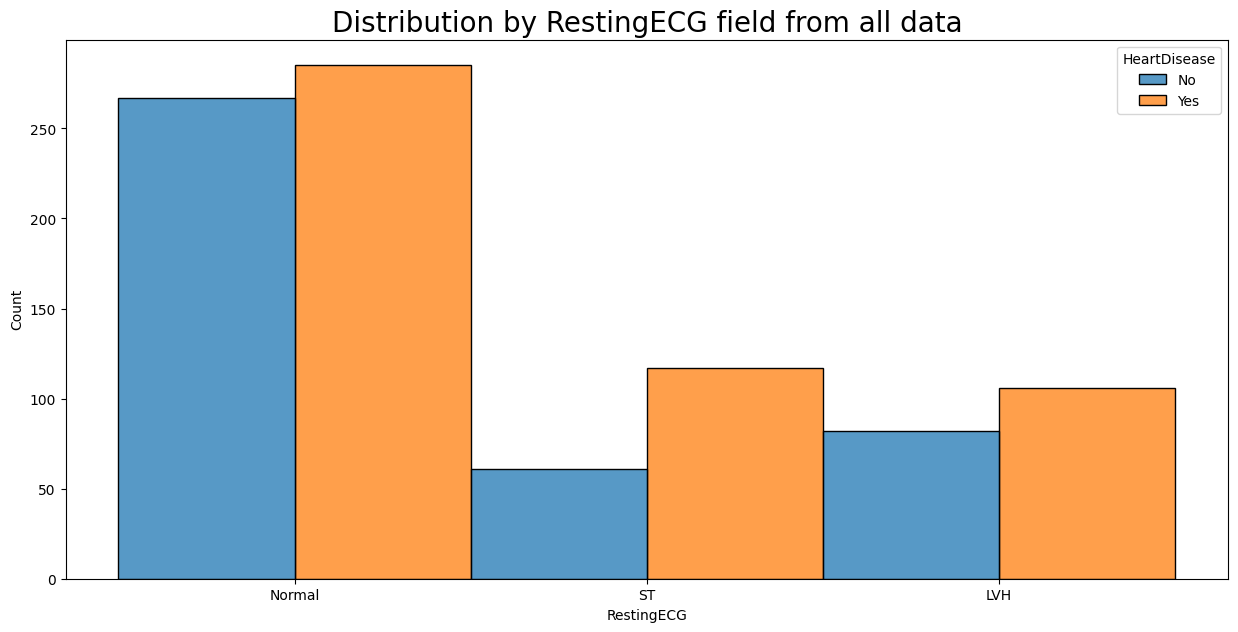

In [52]:
# When using a hue semantic with discrete data, it can make sense to “dodge” the levels:
width, height = 15, 7
plt.rcParams['figure.figsize'] = [width, height]
ax = sns.histplot(data=pd_df_data, x="RestingECG", hue="HeartDisease", multiple="dodge")
plt.title('Distribution by RestingECG field from all data', fontsize = 20) # title with fontsize 20
plt.show()

## Percent of heart disease by RestingECG

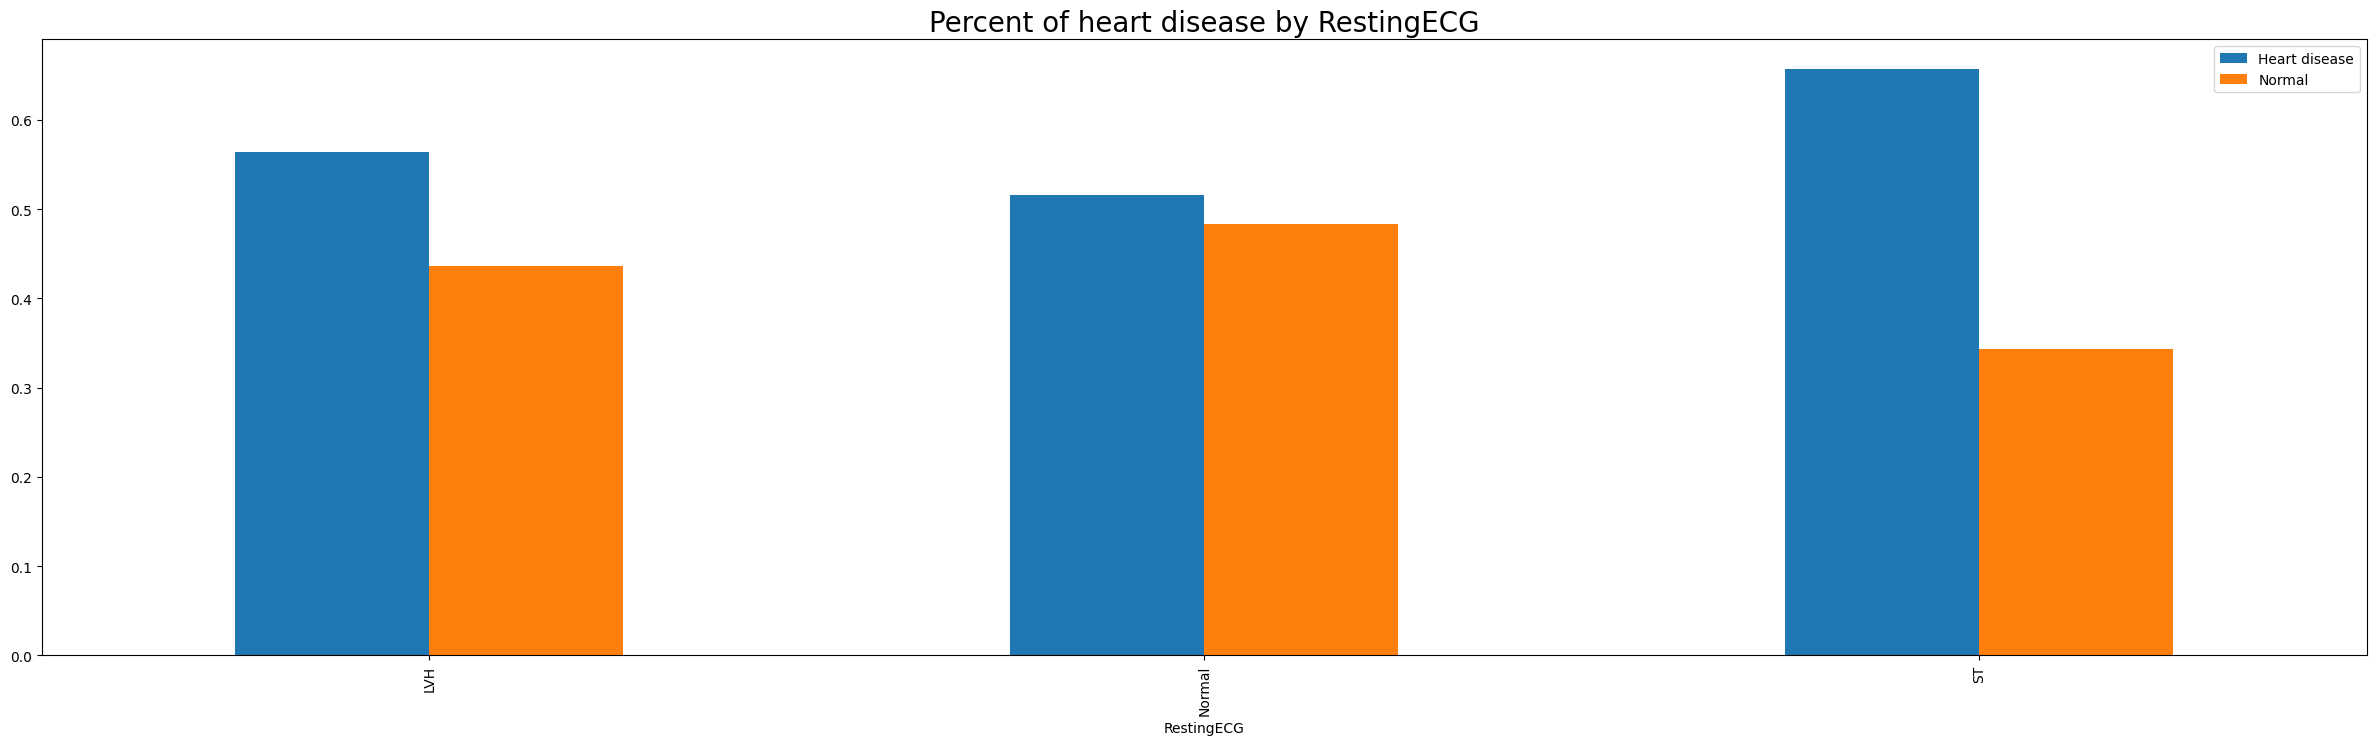

In [55]:
pd_df_count_Transpose = sliceDataByFeatures(pd_df_data, "RestingECG").T

# calculate the percent of leave employee
p0 = pd_df_count_Transpose["Heart disease"] / pd_df_count_Transpose["Total status"]
# calculate the percent of stay employee
p1 = pd_df_count_Transpose["Normal"] / pd_df_count_Transpose["Total status"]
# create a data frame
p = pd.DataFrame({"Heart disease":np.array(p0), "Normal":np.array(p1)}, index=pd_df_count_Transpose.index)
# plot the percent of leave and stay employee
p.plot.bar(figsize=(30, 8))
plt.title('Percent of heart disease by RestingECG', fontsize = 20) # title with fontsize 20
plt.show()